<a href="https://colab.research.google.com/github/ChristabelEyiah/lab-3-feedforward-networks/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


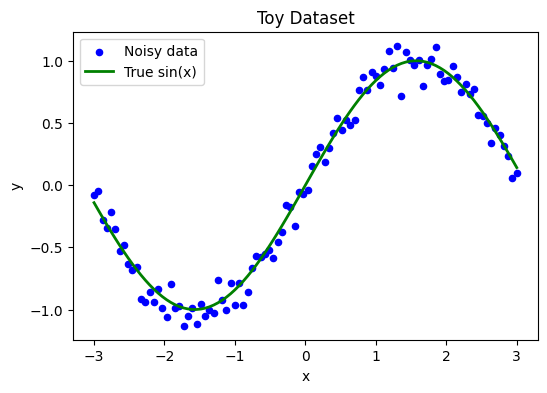

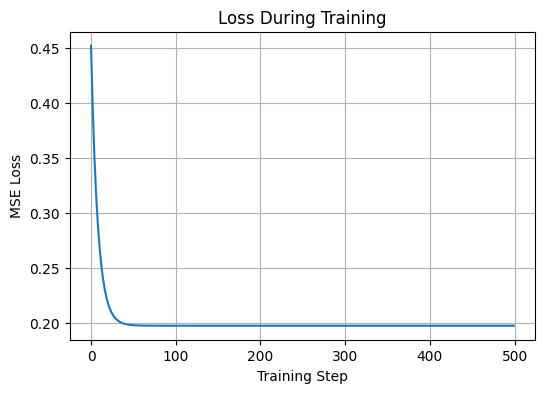

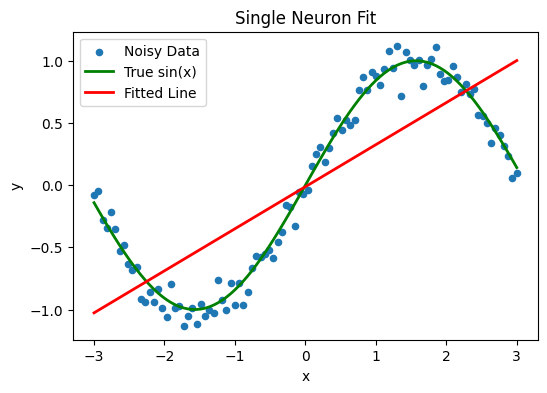

Final weight (w): 0.3380
Final bias (b): -0.0126
Final loss: 0.1974


In [2]:
# Reproducibility
np.random.seed(42)  # single seed controls both param init and data noise

# Initialising parameters
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
learning_rate = 0.01
epochs = 500  # bumped up so the loss curve clearly plateaus
loss_history = []

# Generating the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.figure(figsize=(6,4))
plt.scatter(x, y, color="blue", s=20, label="Noisy data")
plt.plot(x, np.sin(x), color="green", linewidth=2, label="True sin(x)")
plt.title("Toy Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Manual Gradient Descent (batch GD: gradients averaged over all 100 points each step)
for epoch in range(epochs):
    # Forward pass
    y_hat = w * x + b

    # Mean Squared Error Loss
    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)

    # Compute gradients (dLoss/dw, dLoss/db) — derive these by hand and compare
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update parameters (move opposite the gradient to reduce loss)
    w -= learning_rate * dw
    b -= learning_rate * db

# Plotting the loss curve
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Loss During Training")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


# Plotting fitted line
y_pred = w * x + b
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=20, label="Noisy Data")
plt.plot(x, np.sin(x), color="green", linewidth=2, label="True sin(x)")
plt.plot(x, y_pred, color="red", linewidth=2, label="Fitted Line")
plt.title("Single Neuron Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# Final parameters
print(f"Final weight (w): {w:.4f}")
print(f"Final bias (b): {b:.4f}")
print(f"Final loss: {loss_history[-1]:.4f}")

**Student Reasoning**
1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?
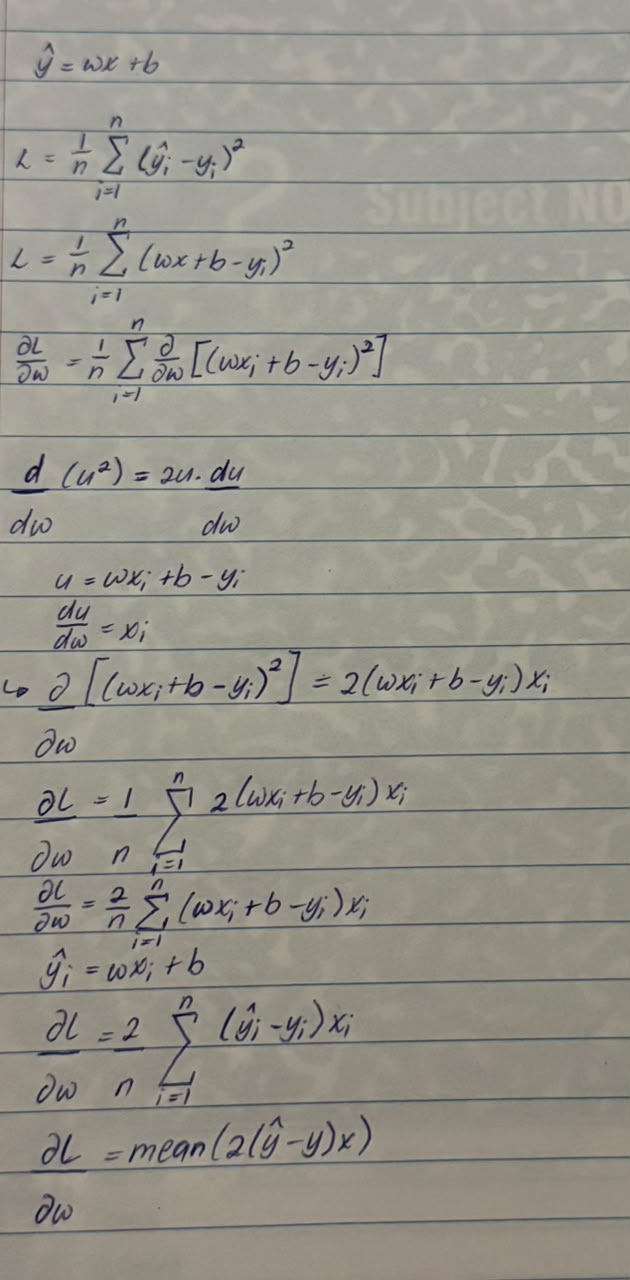


This matches the code: dw = np.mean(2 * (y_hat - y) * x)



2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?

The model is underfitting because a single neuron can only learn a straight line (y^=wx+b). A sine wave is non-linear, so increasing the number of training iterations cannot make a linear model represent it. The model lacks the capacity needed to fit the data.